In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import sklearn

In [56]:
#Reading the dataset
df = pd.read_csv('height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0.5, 0, 'Height')

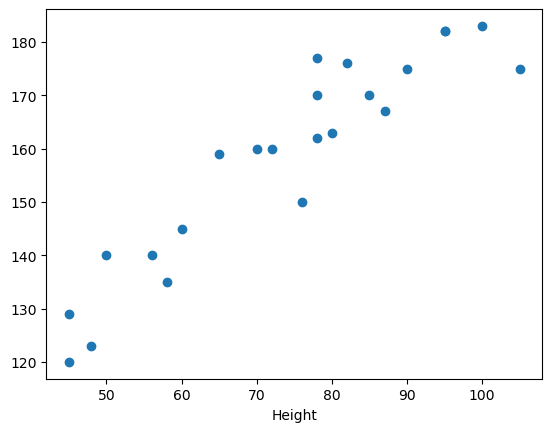

In [57]:
plt.scatter(df['Weight'], df['Height'])
plt.xlabel("Weight")
plt.xlabel("Height")


In [58]:
X = df[['Weight']] # independent features
y = df['Height'] #dependent features

In [59]:
from sklearn.model_selection import train_test_split
X_train , X_test, y_train , y_test = train_test_split(X,y,random_state=42,test_size=0.20)

In [60]:
X.shape

(23, 1)

In [61]:
X_train.shape ,X_test.shape

((18, 1), (5, 1))

In [62]:
from sklearn.preprocessing import StandardScaler

In [63]:
scaler = StandardScaler()

In [64]:
X_train = scaler.fit_transform(X_train)

In [65]:
X_test = scaler.transform(X_test)

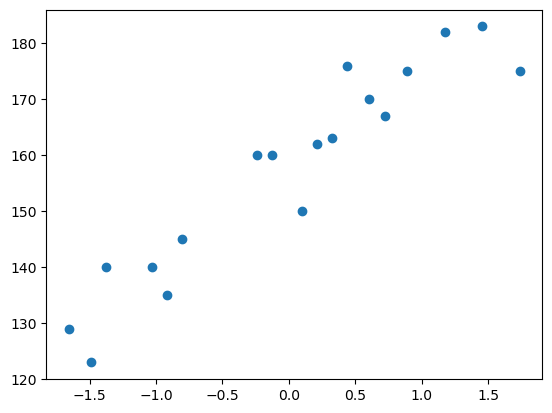

In [70]:
plt.scatter(X_train, y_train)


In [72]:
# Train the simple linear Regression model
from sklearn.linear_model import LinearRegression

In [ ]:
linreg = LinearRegression

In [76]:
linreg.fit(X_train , y_train)

LinearRegression()

In [81]:
linreg.coef_

array([17.03440872])

In [83]:
linreg.intercept_

157.5

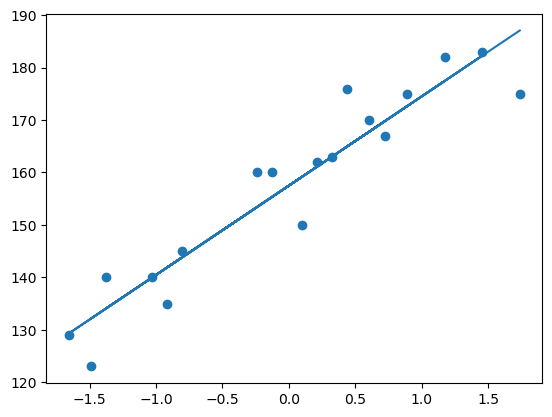

In [90]:
plt.scatter(X_train, y_train)
plt.plot(X_train,linreg.predict(X_train))

### Prediction of train data
1. predicted height output = intercept + coef_(Weights)
y_pred_train = 157.5 + 17.03(X_train)

### prediction of test data
1. predicted height output = intercept + coef_(Weights)
y_pred_train = 157.5 + 17.03(X_test)

In [91]:
y_pred_test = linreg.predict(X_test)


In [93]:
y_pred_test , y_test

(array([161.08467086, 161.08467086, 129.3041561 , 177.45645118,
        148.56507414]),
 15    177
 9     170
 0     120
 8     182
 17    159
 Name: Height, dtype: int64)

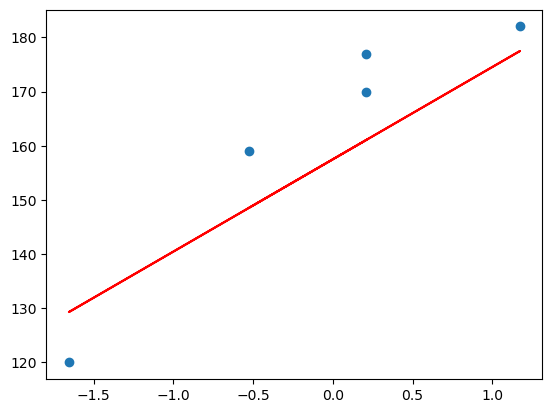

In [96]:
plt.scatter(X_test,y_test)
plt.plot(X_test,linreg.predict(X_test),'r')

## Performance Metrics

## mse, mae , rmse

## R Sqaure and adjusted R square

In [100]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test,y_pred_test)
mae = mean_absolute_error(y_test,y_pred_test)
rmse = np.sqrt(mae)
print('Mean abosulut error :' ,mae)
print('Mean squared error :' ,mse)
print('Root mean square error :' ,rmse)

Mean abosulut error : 9.822657814519227
Mean squared error : 109.77592599051654
Root mean square error : 3.134111965855596


### Rsquare 
### Formula
### R^2 = 1-SSR/SST

### R^2 = coefficient of determination 
### SSR = sum of squares of residuals SST = total sum of squares

In [102]:
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred_test)
print(score)

0.7769869860423441


**Adjusted R2 = 1 – [(1-R2)*(n-1)/(n-k-1)]**

where:

R2: The R2 of the model
n: The number of observations
k: The number of predictor variables

In [103]:
#display adjusted R-squared
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.7026493147231254

In [104]:
# Suppose we have to predict the height for 80 kg weight
# 1. first we need to convert it into standard form
weight_scaled = scaler.transform([[80]])
weight_scaled


/usr/lib/python3/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.32350772]])

In [112]:
predicted_height_80 = linreg.predict(weight_scaled[[0]])
print('Height for 80kg weight :', predicted_height_80)

Height for 80kg weight : [163.01076266]


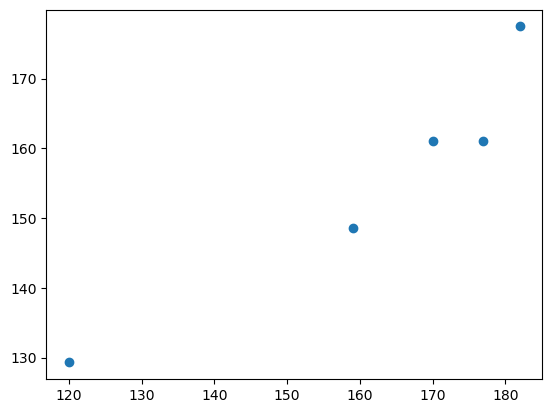

In [113]:
## Assumptions 
## Plot a scatter for te prediction
plt.scatter(y_test , y_pred_test)

In [115]:
## Residuals
residuals = y_test - y_pred_test
residuals

15    15.915329
9      8.915329
0     -9.304156
8      4.543549
17    10.434926
Name: Height, dtype: float64

/tmp/ipykernel_435107/2407826066.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals , kde = 'True')


<AxesSubplot: xlabel='Height', ylabel='Density'>

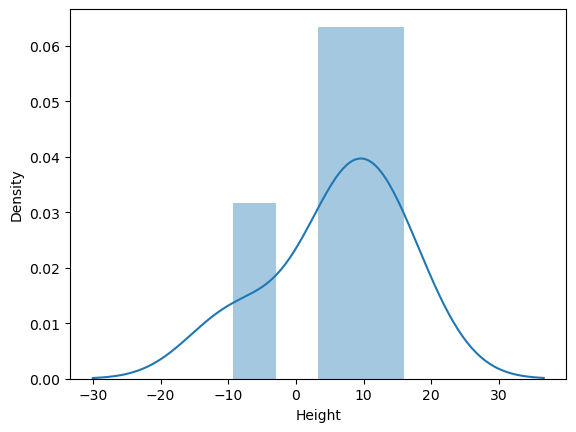

In [119]:
## plot this residual---kinda normal distribution
import seaborn as sns
sns.distplot(residuals , kde = 'True')

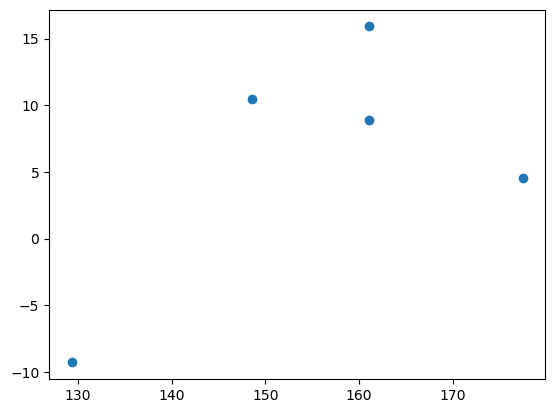

In [120]:
## Scatter plot iwth respoect to predictions and residuals
plt.scatter(y_pred_test , residuals)

In [121]:
# The task is completed , the only thing left is to pickle the file for deployment ..Will be done in later notebooks..>>